# Model Training & Evaluation
Project: heart-disease-xgboost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from xgboost import XGBClassifier

print("All imports successful!")

All imports successful!


In [2]:
df = pd.read_csv('../data/raw/heart.csv')

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Features   : {list(X.columns)}")

Train size : (242, 13)
Test size  : (61, 13)
Features   : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [3]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 40)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob)*100:.2f}%")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Disease', 'Heart Disease']))

  Accuracy  : 81.97%
  ROC-AUC   : 87.66%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.95      0.64      0.77        28
Heart Disease       0.76      0.97      0.85        33

     accuracy                           0.82        61
    macro avg       0.85      0.81      0.81        61
 weighted avg       0.85      0.82      0.81        61



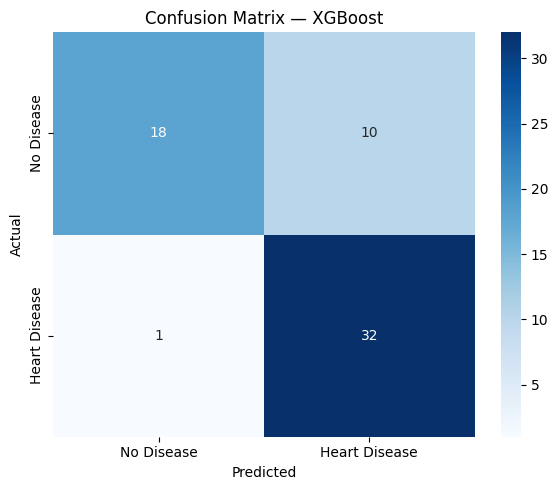

Saved!


In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150)
plt.show()
print("Saved!")

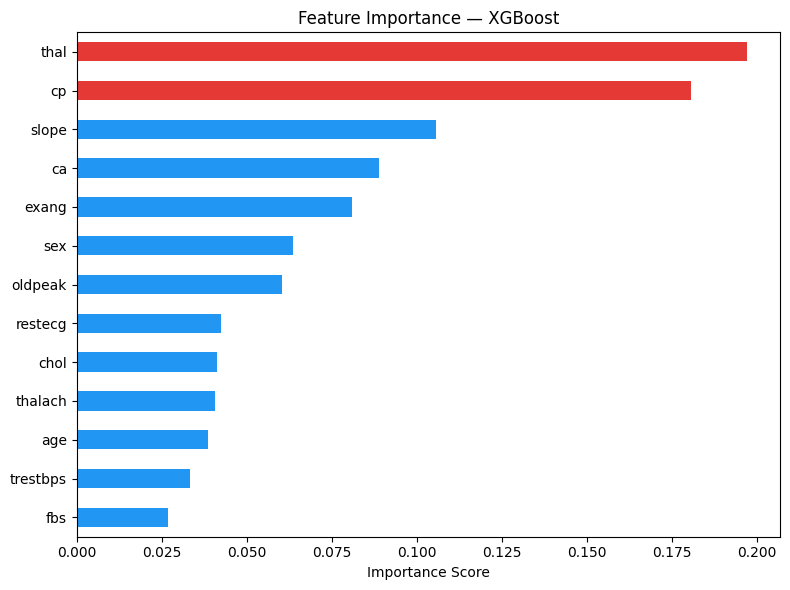

In [6]:
feat_imp = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values()

plt.figure(figsize=(8, 6))
colors = ['#2196F3' if v < feat_imp.max()*0.7 else '#E53935' 
          for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

In [7]:
joblib.dump(model, '../models/xgboost_model.pkl')

# Feature names bhi save karo (Streamlit ke liye zaroori)
import json
with open('../models/feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)

print("Model saved  →  models/xgboost_model.pkl")
print("Features saved →  models/feature_names.json")

Model saved  →  models/xgboost_model.pkl
Features saved →  models/feature_names.json
